In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

Saving superstore.csv to superstore (1).csv


In [25]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
df.shape

(9994, 21)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [28]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [31]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [32]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [33]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

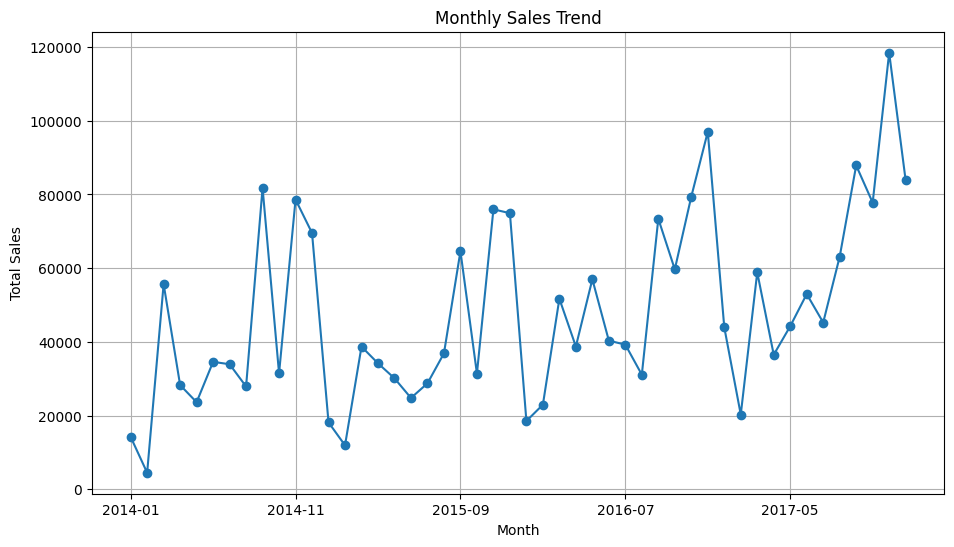

In [41]:
### Monthly Sales Trend

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(11,6))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

 **Observation**:
The line chart shows how sales changed month by month.
This helps identify seasonal trends and periods of high or low sales.

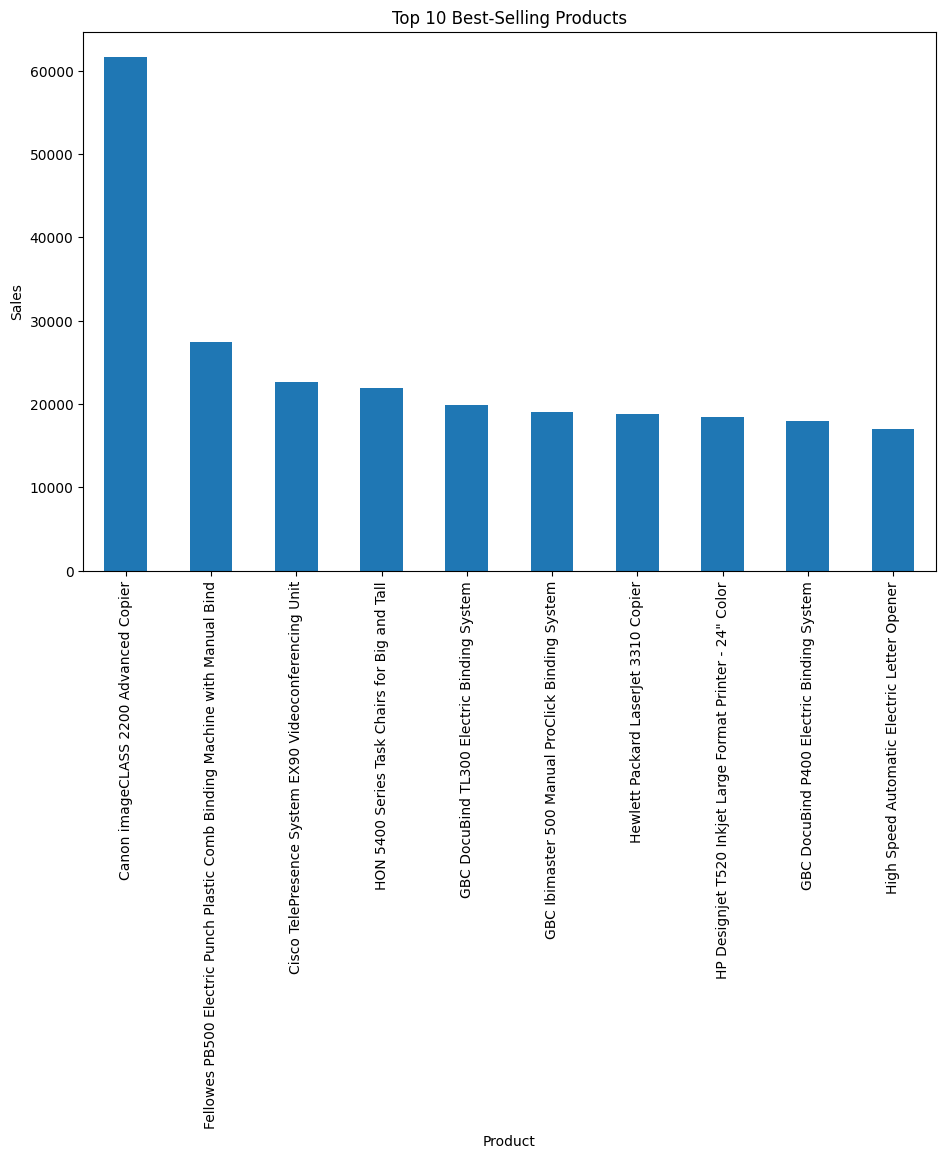

In [43]:
### Top 10 Best-Selling Products

top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(11,7))
top_products.plot(kind="bar")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

**Observation:**
These are the top 10 products generating the highest sales revenue.
The business should maintain sufficient inventory for these products.

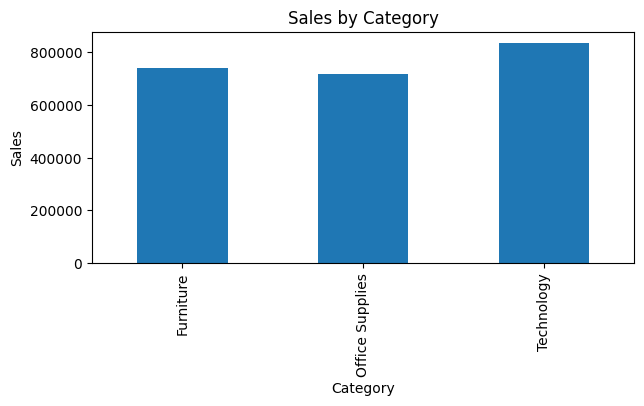

In [45]:
### Sales by Category

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7,3))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

 **Observation:**
This chart compares the total sales across different product categories.
It helps identify the strongest-performing categories.

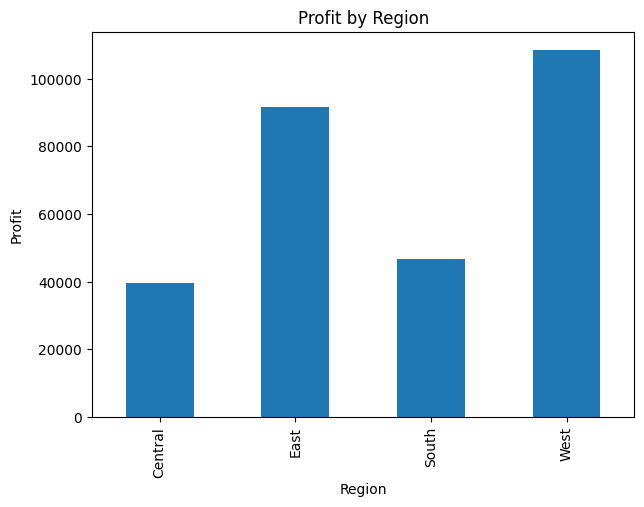

In [47]:
### Profit by Region

region_profit = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(7,5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

**Observation:**
This visualization shows which regions generate the highest profit for the company.

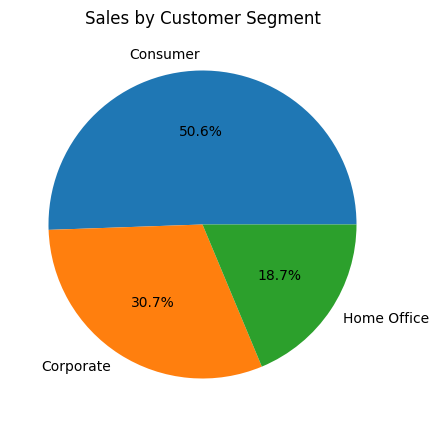

In [49]:
### Customer Segment Sales

segment_sales = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(5,5))
segment_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Customer Segment")
plt.ylabel("")
plt.show()

**Observation:**
The pie chart illustrates the contribution of each customer segment to total sales.

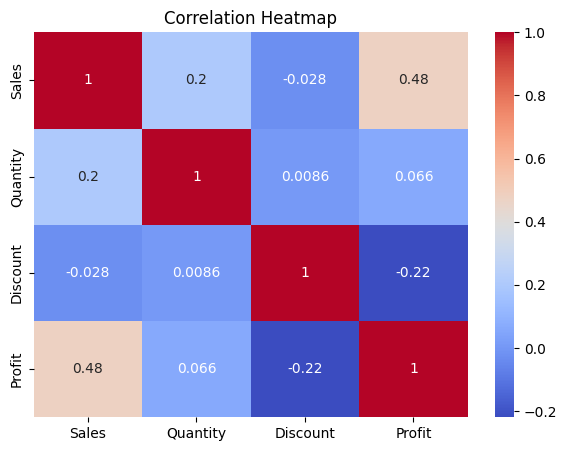

In [51]:
### Correlation Heatmap

plt.figure(figsize=(7,5))
sns.heatmap(df[["Sales", "Quantity", "Discount", "Profit"]].corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

**Observation:**
The heatmap shows the relationship between Sales, Quantity, Discount, and Profit.
A value close to 1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship.

# Business Recommendations

1. Focus marketing efforts on the top-selling products to maximize revenue.

2. Review products or regions with lower profit margins and optimize pricing or discount strategies.

3. Strengthen sales in underperforming customer segments through targeted promotions and loyalty programs.